<a href="https://colab.research.google.com/github/d-kemolife/SASQOF-Security-Aware-Selective-Quantization-and-Optimization-Framework-/blob/main/SASQOF_Google_Colab_Windows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SASQOF dataset: ASR646 reproducibility in Google Colab

Open this notebook in https://colab.research.google.com using your Windows browser: **File → Upload notebook**. Select a standard Python CPU runtime (hardware accelerator **None**) and execute cells in order. No Windows Python installation or Windows path configuration is needed; computation runs on the hosted runtime.

This self-contained notebook embeds the five exact experiment scripts and launcher from the revised manuscript. Upload only your original CSV when prompted. It executes eight model types × five seeds × three protocols, data auditing, 1,200 functional security checks and conditional statistical summaries. No synthetic dataset is substituted.

Dependencies install in an isolated environment to avoid replacing Colab's notebook packages. The original software versions are pinned; installation stops if the hosted Python/runtime cannot support them. Original execution used Python 3.12.14 and Linux x86_64. Hardware-dependent timing will differ on Colab. Notebook structure and source integrity are checked locally; this notebook has not been executed in a hosted Colab session.

Important interpretation: chronological validation/test labels are constant, and identical input vectors repeat extensively. Do not interpret perfect chronological accuracy as evidence of useful generalization. This is a CPU reference implementation, with no ESP32 firmware or FP16 deployment.

Hosted runtimes are temporary. Download result archives before disconnecting. Source: https://research.google.com/colaboratory/faq.html


## Verified dataset identity

Upload **SASQOF_Dataset.csv**. It has **10,257 data rows and 13 columns**. Its normalized headers and every data cell match the previously supplied CSV; the source bytes have changed. The analyses are unchanged, while file identity checks and audit hashes now use this supplied file.

**SHA-256:**
```text
7025b53ed9842d9473b8d5f521639c09225d35feafd5be5254c982a170536ed3
```


## 1. Materialize the embedded implementation
Run this cell first, including after a runtime reset. It recreates code without needing a GitHub repository or ZIP upload.

In [5]:
from pathlib import Path
import json, hashlib, sys, subprocess, platform, shutil
WORK = Path('/content/sasqof_asr646')
WORK.mkdir(parents=True, exist_ok=True)
SOURCES = {'code/audit_and_security.py': '"""Audit actual CSV and run packet rejection checks using its sensor payloads."""\nfrom pathlib import Path\nimport argparse,hashlib,json,secrets,tempfile\nimport numpy as np,pandas as pd\nfrom security import Receiver,encode_packet,sign\nfrom evaluate import FEATURES,TARGETS\n\ndef main():\n ap=argparse.ArgumentParser();ap.add_argument(\'csv\',type=Path);ap.add_argument(\'--out\',type=Path,required=True);a=ap.parse_args();a.out.mkdir(parents=True,exist_ok=True)\n d=pd.read_csv(a.csv);original=d.columns.tolist();d.columns=d.columns.str.strip();t=pd.to_datetime(d.datetime,utc=True)\n stats={c:dict(min=float(d[c].min()),median=float(d[c].median()),max=float(d[c].max()),mean=float(d[c].mean()),sd=float(d[c].std())) for c in FEATURES}\n rules={};agreement={}\n for x,y in zip(FEATURES[:3],TARGETS):\n  positive=d.loc[d[y]==1,x];negative=d.loc[d[y]==0,x]\n  rules[y]=dict(max_active_input=float(positive.max()),min_inactive_input=float(negative.min()),matches_less_than_50=int(((d[x]<50).astype(int)==d[y]).sum()),total=len(d))\n  agreement[y]=int(((d[x]<50).astype(int)==d[y]).sum())\n # Observed agreement is an audit finding, not evidence about how labels were generated.\n report=dict(sha256=hashlib.sha256(a.csv.read_bytes()).hexdigest(),rows=len(d),original_columns=original,normalized_columns=d.columns.tolist(),timestamp_start=str(t.min()),timestamp_end=str(t.max()),gap_seconds=t.diff().dt.total_seconds().describe().to_dict(),unique_ids=int(d.id.nunique()),duplicate_timestamps=int(t.duplicated().sum()),missing=d.isna().sum().to_dict(),infinite=int(np.isinf(d[FEATURES+TARGETS].to_numpy()).sum()),unique_feature_vectors=len(d[FEATURES].drop_duplicates()),repeated_feature_rows=int(d[FEATURES].duplicated().sum()),conflicting_labels_for_same_inputs=int((d.groupby(FEATURES)[TARGETS].nunique().max(axis=1)>1).sum()),positives={c:int(d[c].sum()) for c in TARGETS},rain_positive=int(d.is_raining.sum()),zero_environment_rows=d.loc[(d.temperature==0)&(d.humidity==0)&(d.dew_point==0),\'id\'].astype(int).tolist(),threshold_agreement=rules,combined_pattern_matches=bool(np.all(d[\'IRRIGATION PATTERN\']==100*d[TARGETS[0]]+10*d[TARGETS[1]]+d[TARGETS[2]])),statistics=stats,provenance=\'User identifies real sensor measurements; collection site, calibration, target-generation method and license not supplied\',exclusions=\'None; zero-coded measurements retained and flagged; soil zeros not declared missing\')\n (a.out/\'audit.json\').write_text(json.dumps(report,indent=2,allow_nan=False))\n d[FEATURES].describe().to_csv(a.out/\'feature_statistics.csv\');d[TARGETS].value_counts().rename(\'count\').to_csv(a.out/\'label_patterns.csv\')\n security=[]\n for case in [\'valid\',\'tampered\',\'wrong_key\',\'replay\',\'restart_replay\',\'expired\',\'future\',\'revoked_epoch\',\'unknown_device\',\'malformed\',\'failed_tag_state\',\'out_of_order\']:\n  correct=0\n  with tempfile.TemporaryDirectory() as td:\n   key=secrets.token_bytes(32);keys={\'node\':(\'epoch\',key)};db=str(Path(td)/\'state.sqlite\');r=Receiver(db,keys)\n   try:\n    for i in range(100):\n     payload={c:float(d.iloc[i][c]) for c in FEATURES};seq=i*3+1\n     msg=encode_packet(\'node\',\'epoch\',seq,payload,timestamp=1000);tag=sign(key,msg)\n     if case in [\'replay\',\'restart_replay\',\'out_of_order\']:\n      r.verify(msg,tag,now=1000)\n      if case==\'restart_replay\':r.close();r=Receiver(db,keys)\n      if case==\'out_of_order\':msg=encode_packet(\'node\',\'epoch\',seq-1 if seq>1 else 0,payload,timestamp=1000);tag=sign(key,msg)\n     elif case==\'tampered\':msg=msg.replace(b\'"temperature":\',b\'"temperature":9\',1)\n     elif case==\'wrong_key\':tag=sign(secrets.token_bytes(32),msg)\n     elif case in [\'expired\',\'future\',\'revoked_epoch\',\'unknown_device\']:\n      msg=encode_packet(\'unknown\' if case==\'unknown_device\' else \'node\',\'old\' if case==\'revoked_epoch\' else \'epoch\',seq,payload,timestamp=900 if case==\'expired\' else 1100 if case==\'future\' else 1000);tag=sign(key,msg)\n     elif case==\'malformed\':msg=b\'{}\';tag=sign(key,msg)\n     elif case==\'failed_tag_state\':\n      high=encode_packet(\'node\',\'epoch\',seq+100000,payload,timestamp=1000)\n      try:r.verify(high,bytes(32),now=1000)\n      except ValueError:pass\n      else:raise RuntimeError(\'Failed authentication was accepted\')\n     try:\n      returned=r.verify(msg,tag,now=1000)\n      correct+=int(case in [\'valid\',\'failed_tag_state\'] and returned==payload)\n     except ValueError:\n      correct+=int(case not in [\'valid\',\'failed_tag_state\'])\n   finally:r.close()\n  security.append(dict(case=case,trials=100,expected_behavior_checks_passed=correct))\n if any(c[\'expected_behavior_checks_passed\']!=100 for c in security):raise RuntimeError(\'Security checks failed\')\n (a.out/\'security_trials.json\').write_text(json.dumps(security,indent=2))\n print(json.dumps({\'audit_rows\':len(d),\'security_checks\':sum(c[\'expected_behavior_checks_passed\'] for c in security)}))\nif __name__==\'__main__\':main()\n', 'code/summarize.py': '"""Summarize exported predictions and perform exploratory group bootstrap."""\nfrom pathlib import Path\nimport json, argparse\nimport numpy as np,pandas as pd\nfrom scipy.stats import t\nfrom evaluate import FEATURES,TARGETS\n\ndef main():\n ap=argparse.ArgumentParser();ap.add_argument(\'csv\',type=Path);ap.add_argument(\'--results\',type=Path,required=True);a=ap.parse_args()\n d=pd.read_csv(a.csv);d.columns=d.columns.str.strip();g=d.groupby(FEATURES,sort=False,dropna=False).ngroup().to_numpy()\n root=a.results;names=[r[\'model\'] for r in json.loads((root/\'summary.json\').read_text())];rng=np.random.default_rng(20261002)\n tables={};pairs=[];draws=None\n for name in names:\n  p=pd.read_csv(root/\'seed_42\'/f\'{name}_predictions.csv\');ids=p.original_csv_row.to_numpy();ys=p[[c+\'_true\' for c in TARGETS]].to_numpy();pred=p[[c+\'_pred\' for c in TARGETS]].to_numpy();good=np.all(ys==pred,axis=1);keys=g[ids];groups=np.unique(keys)\n  counts=np.array([(keys==k).sum() for k in groups]);correct=np.array([good[keys==k].sum() for k in groups]);\n  if draws is None:draws=rng.integers(0,len(groups),size=(2000,len(groups)))\n  v=correct[draws].sum(axis=1)/counts[draws].sum(axis=1)\n  tables[name]=dict(seed=42,subset_accuracy=float(good.mean()),conditional_feature_group_bootstrap_95CI=np.percentile(v,[2.5,97.5]).tolist(),groups=len(groups),replicates=2000)\n for other in [\'LSTM_FP32\',\'LSTM_dynamic_INT8_all\',\'DecisionTree\',\'MLP_FP32\']:\n  diff=[];identical=True\n  for seed in range(42,47):\n   p=pd.read_csv(root/f\'seed_{seed}\'/\'LSTM_selective_INT8_FP32_predictions.csv\');q=pd.read_csv(root/f\'seed_{seed}\'/f\'{other}_predictions.csv\')\n   yp=p[[c+\'_true\' for c in TARGETS]].to_numpy();pp=p[[c+\'_pred\' for c in TARGETS]].to_numpy();qp=q[[c+\'_pred\' for c in TARGETS]].to_numpy();identical=identical and np.array_equal(pp,qp)\n   diff.append(float(np.all(yp==pp,axis=1).mean()-np.all(yp==qp,axis=1).mean()))\n  m=float(np.mean(diff));se=float(np.std(diff,ddof=1)/np.sqrt(5));pairs.append(dict(comparison=\'Selective minus \'+other,mean_subset_accuracy_difference=m,seed_only_t95CI=[m-t.ppf(.975,4)*se,m+t.ppf(.975,4)*se],paired_differences=diff,predictions_identical_all_seeds=identical))\n obj=dict(interpretation=\'Exploratory conditional intervals. Five-seed intervals describe training variation on one fixed split. Feature-group bootstrap assumes sampled groups are exchangeable despite temporal similarity; neither establishes site/season generalization.\',seed42_group_bootstrap=tables,paired_seed_comparisons=pairs)\n (root/\'statistical_analysis.json\').write_text(json.dumps(obj,indent=2))\n print(json.dumps(obj,indent=2))\nif __name__==\'__main__\':main()\n', 'code/test_security.py': '"""Mechanical reference-protocol tests; no manuscript data or device experiments."""\nimport secrets\nimport tempfile\nimport unittest\nfrom pathlib import Path\nfrom security import Receiver, encode_packet, sign\n\n\nclass SecurityChecks(unittest.TestCase):\n    def setUp(self):\n        self.tmp = tempfile.TemporaryDirectory()\n        self.path = str(Path(self.tmp.name)/\'state.sqlite\')\n        self.key = secrets.token_bytes(32)\n        self.keys = {\'node-a\': (\'epoch-1\', self.key)}\n        self.r = Receiver(self.path, self.keys)\n    def tearDown(self):\n        self.r.close()\n        self.tmp.cleanup()\n    def packet(self, seq=1, stamp=1000, device=\'node-a\', epoch=\'epoch-1\'):\n        msg = encode_packet(device, epoch, seq, {\'reading\': 30}, timestamp=stamp)\n        return msg, sign(self.key, msg)\n    def test_valid(self):\n        self.assertEqual(self.r.verify(*self.packet(), now=1000), {\'reading\': 30})\n    def test_tampered(self):\n        msg, tag = self.packet()\n        with self.assertRaises(ValueError):\n            self.r.verify(msg.replace(b\'30\', b\'31\'), tag, now=1000)\n    def test_wrong_key(self):\n        msg, tag = self.packet()\n        with self.assertRaises(ValueError):\n            self.r.verify(msg, sign(secrets.token_bytes(32), msg), now=1000)\n    def test_replay(self):\n        self.r.verify(*self.packet(), now=1000)\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(), now=1000)\n    def test_persistent_restart(self):\n        self.r.verify(*self.packet(), now=1000)\n        self.r.close()\n        self.r = Receiver(self.path, self.keys)\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(), now=1000)\n    def test_failed_authentication_does_not_advance_counter(self):\n        msg, tag = self.packet(seq=100)\n        with self.assertRaises(ValueError):\n            self.r.verify(msg, bytes(32), now=1000)\n        self.r.verify(*self.packet(seq=1), now=1000)\n    def test_out_of_order(self):\n        self.r.verify(*self.packet(seq=2), now=1000)\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(seq=1), now=1000)\n    def test_expired(self):\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(stamp=900), now=1000)\n    def test_future(self):\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(stamp=1100), now=1000)\n    def test_revoked_epoch(self):\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(epoch=\'old-epoch\'), now=1000)\n    def test_unknown_device(self):\n        with self.assertRaises(ValueError):\n            self.r.verify(*self.packet(device=\'unknown\'), now=1000)\n    def test_malformed(self):\n        with self.assertRaises(ValueError):\n            self.r.verify(b\'{}\', sign(self.key, b\'{}\'), now=1000)\n\n\nif __name__ == \'__main__\':\n    unittest.main(verbosity=2)\n', 'code/security.py': '"""Corrective CPU reference protocol, not recovered original firmware."""\nimport hashlib\nimport hmac\nimport json\nimport math\nimport sqlite3\nimport time\n\n\ndef encode_packet(device, epoch, seq, payload, timestamp=None):\n    message = {"version": 1, "device": device, "epoch": epoch,\n               "sequence": seq, "timestamp": time.time() if timestamp is None else timestamp,\n               "payload": payload}\n    return json.dumps(message, sort_keys=True, separators=(",", ":"),\n                      allow_nan=False).encode("utf-8")\n\n\ndef sign(key, message):\n    if not isinstance(key, bytes) or len(key) < 32:\n        raise ValueError("Provision a device-specific key with at least 32 random bytes")\n    return hmac.new(key, message, hashlib.sha256).digest()\n\n\nclass Receiver:\n    """One active authorized (epoch, key) per device; SQLite persists high-water marks.\n\n    Deployment needs authenticated provisioning, protected keys, a trustworthy clock,\n    sender counter persistence, controlled epoch rotation, and durable storage.\n    SQLite provides a CPU reference only; it is not an ESP32 storage implementation.\n    """\n    def __init__(self, database, provisioned_keys, max_age=60.0, future_tolerance=10.0):\n        self.keys = dict(provisioned_keys)\n        for epoch, key in self.keys.values():\n            if not isinstance(epoch, str) or not epoch or len(key) < 32:\n                raise ValueError("Invalid provisioned epoch/key")\n        self.max_age = float(max_age)\n        self.future_tolerance = float(future_tolerance)\n        self.db = sqlite3.connect(database, timeout=10, isolation_level=None)\n        self.db.execute("PRAGMA synchronous=FULL")\n        self.db.execute("CREATE TABLE IF NOT EXISTS counters "\n                        "(device TEXT, epoch TEXT, seq INTEGER, PRIMARY KEY(device,epoch))")\n\n    def close(self):\n        self.db.close()\n\n    def verify(self, message, tag, now=None):\n        if not isinstance(message, bytes) or not isinstance(tag, bytes):\n            raise ValueError("Packet and tag must be bytes")\n        if len(message) > 8192 or len(tag) != 32:\n            raise ValueError("Invalid packet length")\n        try:\n            packet = json.loads(message)\n            if not isinstance(packet, dict) or set(packet) != {\n                    "version", "device", "epoch", "sequence", "timestamp", "payload"}:\n                raise ValueError("Invalid packet schema")\n            device = packet["device"]\n            if not isinstance(device, str) or not isinstance(packet["epoch"], str):\n                raise ValueError("Invalid identity fields")\n            epoch, key = self.keys[device]\n        except (ValueError, KeyError, TypeError, UnicodeError) as exc:\n            raise ValueError("Unknown device or malformed packet") from exc\n        # The exact received bytes are authenticated, not a reserialized payload.\n        if not hmac.compare_digest(sign(key, message), tag):\n            raise ValueError("Authentication failure")\n        if type(packet["version"]) is not int or packet["version"] != 1:\n            raise ValueError("Unsupported version")\n        if packet["epoch"] != epoch:\n            raise ValueError("Unauthorized or revoked key epoch")\n        seq = packet["sequence"]\n        stamp = packet["timestamp"]\n        if type(seq) is not int or not 1 <= seq < 2**63:\n            raise ValueError("Invalid sequence")\n        if type(stamp) not in (int, float) or not math.isfinite(stamp):\n            raise ValueError("Invalid timestamp")\n        now = time.time() if now is None else now\n        if not -self.future_tolerance <= now-stamp <= self.max_age:\n            raise ValueError("Expired or future packet")\n        if not isinstance(packet["payload"], dict):\n            raise ValueError("Invalid payload")\n        # Lock, compare, and commit together to avoid duplicate concurrent acceptance.\n        self.db.execute("BEGIN IMMEDIATE")\n        try:\n            row = self.db.execute("SELECT seq FROM counters WHERE device=? AND epoch=?",\n                                  (device, epoch)).fetchone()\n            if row is not None and seq <= row[0]:\n                raise ValueError("Duplicate or replayed sequence")\n            self.db.execute("INSERT INTO counters VALUES (?,?,?) ON CONFLICT(device,epoch) "\n                            "DO UPDATE SET seq=excluded.seq", (device, epoch, seq))\n            self.db.execute("COMMIT")\n        except Exception:\n            self.db.execute("ROLLBACK")\n            raise\n        return packet["payload"]\n', 'code/evaluate.py': '"""Corrective CPU evaluation run on the author supplied CSV in October 2026.\nThis is new reference code and does not reproduce the undocumented historical run.\nChronological evaluation is primary; unique-feature-group random splitting is a\nclass-diverse sensitivity analysis, not evidence of future or site generalization.\n"""\nimport argparse\nimport copy\nimport hashlib\nimport io\nimport json\nimport platform\nimport random\nimport secrets\nimport sys\nimport time\nimport warnings\nfrom pathlib import Path\n\nimport joblib\nimport numpy as np\nimport pandas as pd\nimport sklearn\nimport torch\nfrom torch import nn\nfrom sklearn.dummy import DummyClassifier\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.tree import DecisionTreeClassifier\nfrom security import Receiver, encode_packet, sign\n\nFEATURES = [\'sandy_percent\', \'clay_percent\', \'loamy_percent\',\n            \'temperature\', \'humidity\', \'dew_point\', \'is_raining\']\nTARGETS = [\'sandy_pump_active\', \'clay_pump_active\', \'loamy_pump_active\']\n\n\ndef save_json(path, obj):\n    Path(path).write_text(json.dumps(obj, indent=2, allow_nan=False), encoding=\'utf-8\')\n\n\ndef ratio(a, b):\n    return None if b == 0 else float(a/b)\n\n\ndef metrics(y, pred):\n    rows = []\n    for j, name in enumerate(TARGETS):\n        t, v = y[:, j].astype(bool), pred[:, j].astype(bool)\n        tp, tn = int((t & v).sum()), int((~t & ~v).sum())\n        fp, fn = int((~t & v).sum()), int((t & ~v).sum())\n        rows.append(dict(output=name, TP=tp, TN=tn, FP=fp, FN=fn,\n                         positive_support=int(t.sum()), negative_support=int((~t).sum()),\n                         precision=ratio(tp, tp+fp), recall=ratio(tp, tp+fn),\n                         f1=ratio(2*tp, 2*tp+fp+fn), specificity=ratio(tn, tn+fp),\n                         false_positive_rate=ratio(fp, fp+tn),\n                         false_negative_rate=ratio(fn, fn+tp)))\n    f1s = [row[\'f1\'] for row in rows]\n    return dict(subset_accuracy=float(np.all(y == pred, axis=1).mean()),\n                label_accuracy=float((y == pred).mean()),\n                macro_f1=None if None in f1s else float(np.mean(f1s)), per_pump=rows)\n\n\ndef timed(fn, warmup=50, repeats=500):\n    for _ in range(warmup):\n        fn()\n    durations = []\n    for _ in range(repeats):\n        start = time.perf_counter_ns()\n        fn()\n        durations.append((time.perf_counter_ns()-start)/1e6)\n    return dict(mean_ms=float(np.mean(durations)), sd_ms=float(np.std(durations, ddof=1)),\n                median_ms=float(np.median(durations)), p95_ms=float(np.percentile(durations,95)),\n                warmup=warmup, repetitions=repeats, batch_size=1), durations\n\n\nclass IrrigationLSTM(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.lstm = nn.LSTM(7, 32, num_layers=2, batch_first=True)\n        self.fc = nn.Linear(32, 3)\n    def forward(self, x):\n        hidden, _ = self.lstm(x)\n        return self.fc(hidden[:, -1, :])  # logits; sigmoid applied for inference\n\n\nclass IrrigationMLP(nn.Module):\n    def __init__(self, width):\n        super().__init__()\n        self.net = nn.Sequential(nn.Linear(width,32),nn.ReLU(),nn.Linear(32,32),\n                                 nn.ReLU(),nn.Linear(32,3))\n    def forward(self, x):\n        return self.net(x.reshape(x.shape[0],-1))\n\n\ndef train(model, x, y, xv, yv, seed, out):\n    loader = torch.utils.data.DataLoader(\n        torch.utils.data.TensorDataset(torch.from_numpy(x), torch.from_numpy(y)),\n        batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(seed))\n    opt = torch.optim.Adam(model.parameters(),lr=0.01)\n    lossfn = nn.BCEWithLogitsLoss()\n    best, state, history = float(\'inf\'), None, []\n    for epoch in range(10):\n        model.train()\n        train_losses = []\n        for xb,yb in loader:\n            opt.zero_grad();loss=lossfn(model(xb),yb);loss.backward();opt.step()\n            train_losses.append(float(loss.detach()))\n        model.eval()\n        with torch.inference_mode():\n            vl = float(lossfn(model(torch.from_numpy(xv)),torch.from_numpy(yv)))\n        history.append(dict(epoch=epoch+1, mean_batch_training_loss=float(np.mean(train_losses)),\n                            validation_loss=vl))\n        if vl < best:\n            best=vl;state=copy.deepcopy(model.state_dict())\n    model.load_state_dict(state);model.eval()\n    torch.save(state,out)\n    return model, history\n\n\ndef windows(frame, values, labels, length, groups=None):\n    x,y,ids = [],[],[]\n    keys = np.zeros(len(frame),dtype=int) if groups is None else groups\n    for group in pd.unique(keys):\n        positions=np.flatnonzero(keys == group)\n        times=frame.iloc[positions][\'datetime\'].astype(\'int64\').to_numpy()\n        gaps=np.diff(times)\n        positive=gaps[gaps > 0]\n        limit=1.5*float(np.median(positive)) if len(positive) else float(\'inf\')\n        for end in range(length-1,len(positions)):\n            ix=positions[end-length+1:end+1]\n            dt=np.diff(frame.iloc[ix][\'datetime\'].astype(\'int64\').to_numpy())\n            if length > 1 and ((dt <= 0).any() or (dt > limit).any()):\n                continue\n            x.append(values[ix]);y.append(labels[ix[-1]]);ids.append(int(frame.iloc[ix[-1]][\'_row\']))\n    if not x:\n        raise ValueError(\'No valid windows; inspect timestamps, groups, and chosen sequence length\')\n    return np.asarray(x,dtype=np.float32),np.asarray(y,dtype=np.float32),ids\n\n\ndef main():\n    ap=argparse.ArgumentParser()\n    ap.add_argument(\'csv\',type=Path);ap.add_argument(\'--out\',type=Path,required=True)\n    ap.add_argument(\'--sequence-length\',type=int,default=1)\n    ap.add_argument(\'--group-column\',default=None)\n    ap.add_argument(\'--split\',choices=[\'chronological\',\'feature_groups\'],default=\'chronological\')\n    args=ap.parse_args()\n    if args.sequence_length < 1:\n        raise ValueError(\'Sequence length must be positive\')\n    args.out.mkdir(parents=True,exist_ok=False)\n    torch.set_num_threads(1)\n    backend = \'x86\' if \'x86\' in torch.backends.quantized.supported_engines else \'fbgemm\'\n    if backend not in torch.backends.quantized.supported_engines:\n        raise RuntimeError(\'This reference protocol requires a supported x86/fbgemm CPU backend\')\n    torch.backends.quantized.engine=backend\n    df=pd.read_csv(args.csv)\n    df.columns=df.columns.str.strip()\n    required=FEATURES+TARGETS+[\'datetime\']+([args.group_column] if args.group_column else [])\n    missing=[c for c in required if c not in df]\n    if missing:\n        raise ValueError(f\'Missing columns: {missing}\')\n    df[\'_row\']=np.arange(len(df))\n    df[\'datetime\']=pd.to_datetime(df[\'datetime\'],utc=True,errors=\'raise\')\n    if df[\'datetime\'].isna().any():\n        raise ValueError(\'Missing timestamp; audit and document exclusions first\')\n    for c in FEATURES+TARGETS:\n        df[c]=pd.to_numeric(df[c],errors=\'raise\')\n    if np.isinf(df[FEATURES+TARGETS].to_numpy(dtype=float)).any():\n        raise ValueError(\'Infinite measurement; audit and document treatment first\')\n    if df[TARGETS].isna().any().any() or not df[TARGETS].isin([0,1]).all().all():\n        raise ValueError(\'Targets must be complete binary 0/1 labels; never standardize targets\')\n    if not df[\'is_raining\'].dropna().isin([0,1]).all():\n        raise ValueError(\'Confirm rain coding before evaluation\')\n    if args.group_column and df[args.group_column].isna().any():\n        raise ValueError(\'Missing series identity\')\n    duplicate_key=[\'datetime\']+([args.group_column] if args.group_column else [])\n    if df.duplicated(duplicate_key).any():\n        raise ValueError(\'Duplicate timestamps per series; resolve and document first\')\n    df=df.sort_values(\'datetime\',kind=\'stable\').reset_index(drop=True)\n    n=len(df);a=int(n*.70);b=a+int(n*.15)\n    if args.split == \'feature_groups\':\n        if args.sequence_length != 1:\n            raise ValueError(\'Feature-group sensitivity is record-level only\')\n        ids=df.groupby(FEATURES,dropna=False,sort=False).ngroup().to_numpy()\n        df[\'_feature_group\']=ids\n        unique=df.drop_duplicates(\'_feature_group\')\n        # Each feature vector must have one label pattern for this sensitivity.\n        if df.groupby(\'_feature_group\')[TARGETS].nunique().to_numpy().max() > 1:\n            raise ValueError(\'Conflicting labels for identical inputs\')\n        pattern=unique[TARGETS].astype(str).agg(\'\'.join,axis=1)\n        rng=np.random.default_rng(42);tr=[];va=[];te=[]\n        for value in sorted(pattern.unique()):\n            group_ids=unique.loc[pattern==value,\'_feature_group\'].to_numpy().copy()\n            if len(group_ids)<3:raise ValueError(\'Need at least three feature groups per pattern\')\n            rng.shuffle(group_ids)\n            cut1=min(max(1,int(len(group_ids)*.70)),len(group_ids)-2)\n            cut2=cut1+min(max(1,int(len(group_ids)*.15)),len(group_ids)-cut1-1)\n            tr.extend(group_ids[:cut1]);va.extend(group_ids[cut1:cut2]);te.extend(group_ids[cut2:])\n        frames={name:df[df[\'_feature_group\'].isin(ix)].copy() for name,ix in\n                [(\'train\',tr),(\'validation\',va),(\'test\',te)]}\n    else:\n        frames={name:df.iloc[lo:hi].copy() for name,lo,hi in\n                [(\'train\',0,a),(\'validation\',a,b),(\'test\',b,n)]}\n    if min(a,b-a,n-b) < args.sequence_length:\n        raise ValueError(\'Insufficient rows for declared partitions/windows\')\n    if df.iloc[a-1][\'datetime\'] == df.iloc[a][\'datetime\'] or df.iloc[b-1][\'datetime\'] == df.iloc[b][\'datetime\']:\n        raise ValueError(\'Split crosses equal timestamp block; choose grouped boundaries before rerun\')\n    train_raw=frames[\'train\'][FEATURES].to_numpy(dtype=float)\n    if np.isnan(train_raw).all(axis=0).any():\n        raise ValueError(\'A training feature is entirely missing\')\n    imputer=SimpleImputer(strategy=\'median\');imputer.fit(train_raw)\n    scaler=StandardScaler().fit(imputer.transform(train_raw)[:,:6])\n    joblib.dump(dict(imputer=imputer,scaler=scaler,features=FEATURES),args.out/\'preprocessing.joblib\')\n    splits={};members={};counts={}\n    for name,raw_frame in frames.items():\n        f=raw_frame.reset_index(drop=True)\n        v=imputer.transform(f[FEATURES].to_numpy(dtype=float));v[:,:6]=scaler.transform(v[:,:6])\n        # Keep the rain indicator binary after filling from the training-only median.\n        if not np.isin(v[:,-1],[0,1]).all():\n            raise ValueError(\'Training median rain imputation is not binary; choose a documented policy\')\n        splits[name]=windows(f,v,f[TARGETS].to_numpy(dtype=float),args.sequence_length,\n                             None if not args.group_column else f[args.group_column].to_numpy())\n        counts[name]=dict(rows=len(f),windows=len(splits[name][0]),\n                          start=str(f[\'datetime\'].min()),end=str(f[\'datetime\'].max()),\n                          positives={c:int(f[c].sum()) for c in TARGETS})\n        members[name]=dict(raw_rows=f[\'_row\'].astype(int).tolist(),target_rows=splits[name][2])\n    save_json(args.out/\'split_membership.json\',members)\n    audit=dict(csv_sha256=hashlib.sha256(args.csv.read_bytes()).hexdigest(),rows=n,\n               features=FEATURES,targets=TARGETS,metadata_excluded=[\'id\',\'datetime\',\'IRRIGATION PATTERN\'],\n               missing_values={c:int(df[c].isna().sum()) for c in FEATURES},\n               partitions=counts,sequence_length=args.sequence_length,group_column=args.group_column,\n               source_provenance=\'Author identifies real sensor measurements; site, devices, calibration and access license unprovided\',\n               split=args.split,\n               target_generation=\'MUST be supplied by authors\',\n               protocol=\'Corrective CPU evaluation; not original result lineage\')\n    save_json(args.out/\'dataset_audit.json\',audit)\n    save_json(args.out/\'environment.json\',dict(python=sys.version,torch=torch.__version__,\n        numpy=np.__version__,pandas=pd.__version__,sklearn=sklearn.__version__,\n        platform=platform.platform(),processor=platform.processor(),cpu_model=next((l.split(\':\',1)[1].strip() for l in Path(\'/proc/cpuinfo\').read_text().splitlines() if l.startswith(\'model name\')),\'unknown\'),quantized_backend=backend,\n        threads=torch.get_num_threads(),seeds=[42,43,44,45,46],epochs=10,batch_size=64,\n        optimizer=\'Adam\',learning_rate=.01,threshold=.5,checkpoint=\'minimum validation BCE\'))\n    x,y,_=splits[\'train\'];xv,yv,_=splits[\'validation\'];xt,yt,test_ids=splits[\'test\']\n    all_results=[]\n    for seed in [42,43,44,45,46]:\n        random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)\n        folder=args.out/f\'seed_{seed}\';folder.mkdir()\n        fp,hist=train(IrrigationLSTM(),x,y,xv,yv,seed,folder/\'lstm_fp32.pth\')\n        save_json(folder/\'lstm_training.json\',hist)\n        # One trained source; quantization happens only after checkpoint selection.\n        with warnings.catch_warnings():\n            warnings.simplefilter(\'default\')\n            selective=torch.ao.quantization.quantize_dynamic(copy.deepcopy(fp),{nn.LSTM},dtype=torch.qint8)\n            broad=torch.ao.quantization.quantize_dynamic(copy.deepcopy(fp),{nn.LSTM,nn.Linear},dtype=torch.qint8)\n        torch.manual_seed(seed)\n        mlp,hist=train(IrrigationMLP(x.shape[1]*7),x,y,xv,yv,seed,folder/\'mlp_fp32.pth\')\n        save_json(folder/\'mlp_training.json\',hist)\n        models={\'LSTM_FP32\':fp,\'LSTM_dynamic_INT8_all\':broad,\n                \'LSTM_selective_INT8_FP32\':selective,\'MLP_FP32\':mlp}\n        flat=x.reshape(len(x),-1);testflat=xt.reshape(len(xt),-1)\n        tree=DecisionTreeClassifier(max_depth=5,random_state=seed).fit(flat,y.astype(int))\n        forest=RandomForestClassifier(n_estimators=10,max_depth=10,random_state=seed,n_jobs=1).fit(flat,y.astype(int))\n        models.update(DecisionTree=tree,RandomForest=forest)\n        majority=DummyClassifier(strategy=\'most_frequent\').fit(flat,y.astype(int))\n        models[\'Majority\']=majority\n        logistic=[]\n        for j in range(3):\n            clf=DummyClassifier(strategy=\'most_frequent\') if len(np.unique(y[:,j]))==1 else LogisticRegression(max_iter=2000,random_state=seed)\n            logistic.append(clf.fit(flat,y[:,j].astype(int)))\n        models[\'LogisticRegression\']=logistic\n        for name,model in models.items():\n            if isinstance(model,nn.Module):\n                model.eval()\n                with torch.inference_mode():\n                    probabilities=torch.sigmoid(model(torch.from_numpy(xt))).numpy()\n                pred=(probabilities >= .5).astype(int)\n                sample=torch.from_numpy(xt[:1])\n                def run():\n                    with torch.inference_mode():\n                        return torch.sigmoid(model(sample))\n                target=folder/f\'{name}.pth\';torch.save(model.state_dict(),target)\n                serialization=\'torch.save state_dict\'\n            else:\n                def predict(z):\n                    return np.column_stack([m.predict(z) for m in model]) if isinstance(model,list) else model.predict(z)\n                pred=predict(testflat).astype(int)\n                def run():\n                    return predict(testflat[:1])\n                target=folder/f\'{name}.joblib\';joblib.dump(model,target)\n                serialization=\'joblib; differs from neural state_dict serialization\'\n            timing,samples=timed(run)\n            result=dict(seed=seed,model=name,**metrics(yt,pred),latency=timing,\n                        serialized_bytes=target.stat().st_size,serialized_KiB=target.stat().st_size/1024,\n                        serialization=serialization,peak_runtime_RAM=\'not measured\',\n                        ESP32_flash=\'not measured\',ESP32_SRAM=\'not measured\')\n            save_json(folder/f\'{name}_results.json\',result)\n            pd.DataFrame({\'duration_ms\':samples}).to_csv(folder/f\'{name}_timing.csv\',index=False)\n            predfile=pd.DataFrame({\'original_csv_row\':test_ids})\n            for j,col in enumerate(TARGETS):\n                predfile[col+\'_true\']=yt[:,j].astype(int);predfile[col+\'_pred\']=pred[:,j]\n            predfile.to_csv(folder/f\'{name}_predictions.csv\',index=False)\n            all_results.append(result)\n            print(args.split,args.sequence_length,seed,name,result[\'subset_accuracy\'],flush=True)\n        # CPU packet path timing, including signing only outside the measured call.\n        # Local SQLite commit is deliberately included in receiver overhead.\n        key=secrets.token_bytes(32);receiver=Receiver(str(folder/\'receiver.sqlite\'),{\'benchmark-node\':(\'one\',key)})\n        packet_fields={c:float(df.loc[df[\'_row\']==test_ids[0],c].iloc[0]) for c in FEATURES}\n        if any(not np.isfinite(v) for v in packet_fields.values()):\n            packet_fields={c:float(imputer.statistics_[i]) if not np.isfinite(v) else v for i,(c,v) in enumerate(packet_fields.items())}\n        pairs=[(msg,sign(key,msg)) for msg in [encode_packet(\'benchmark-node\',\'one\',i+1,packet_fields) for i in range(550)]]\n        iterator=iter(pairs)\n        def authenticated_run():\n            message,tag=next(iterator);payload=receiver.verify(message,tag)\n            current=np.array([[payload[c] for c in FEATURES]],dtype=float)\n            current=imputer.transform(current);current[:,:6]=scaler.transform(current[:,:6])\n            # For T>1, trusted history must be held separately. Do not substitute\n            # unverified current data into each history step.\n            window=xt[:1].copy();window[0,-1]=current[0]\n            with torch.inference_mode():\n                return (torch.sigmoid(selective(torch.from_numpy(window))) >= .5).numpy()\n        try:\n            sec,samples=timed(authenticated_run)\n        finally:\n            receiver.close()\n        save_json(folder/\'authenticated_inference.json\',dict(latency=sec,\n            first_packet_bytes=len(pairs[0][0]),packet_byte_range=[min(len(z[0]) for z in pairs),max(len(z[0]) for z in pairs)],tag_bytes=32,history_assumption=\'trusted cached historical window\',\n            scope=\'Verify HMAC, timestamp, persistent sequence; preprocess current record; model; threshold\',\n            note=\'CPU reference timing; sender signing excluded; not an ESP32 or network measurement\'))\n        pd.DataFrame({\'duration_ms\':samples}).to_csv(folder/\'authenticated_inference_timing.csv\',index=False)\n        def plain_run():\n            current=np.array([[packet_fields[c] for c in FEATURES]],dtype=float)\n            current=imputer.transform(current);current[:,:6]=scaler.transform(current[:,:6])\n            window=xt[:1].copy();window[0,-1]=current[0]\n            with torch.inference_mode():\n                return (torch.sigmoid(selective(torch.from_numpy(window))) >= .5).numpy()\n        plain,plain_samples=timed(plain_run)\n        save_json(folder/\'plain_inference.json\',dict(latency=plain,\n            scope=\'Feature array construction, preprocessing, selective model, threshold; no packet verification\',\n            caveat=\'Separate timing blocks; host scheduling and SQLite storage affect differences\'))\n        pd.DataFrame({\'duration_ms\':plain_samples}).to_csv(folder/\'plain_inference_timing.csv\',index=False)\n    summary=[]\n    for name in sorted({z[\'model\'] for z in all_results}):\n        records=[z for z in all_results if z[\'model\']==name]\n        row={\'model\':name,\'runs\':len(records)}\n        for metric in [\'subset_accuracy\',\'label_accuracy\',\'macro_f1\',\'serialized_bytes\']:\n            v=[z[metric] for z in records]\n            row[metric+\'_mean\']=None if None in v else float(np.mean(v))\n            row[metric+\'_sd\']=None if None in v else float(np.std(v,ddof=1))\n        row[\'model_latency_mean_ms\']=float(np.mean([z[\'latency\'][\'mean_ms\'] for z in records]))\n        row[\'model_latency_between_run_sd_ms\']=float(np.std([z[\'latency\'][\'mean_ms\'] for z in records],ddof=1))\n        summary.append(row)\n    save_json(args.out/\'summary.json\',summary)\n    pd.DataFrame(summary).to_csv(args.out/\'summary.csv\',index=False)\n    print(f\'Wrote audited replacement results to {args.out}\')\n\n\nif __name__ == \'__main__\':\n    main()\n', 'requirements.txt': 'torch==2.14.1+cpu\nnumpy==2.3.5\npandas==2.2.3\nscikit-learn==1.8.0\njoblib==1.5.3\nscipy==1.17.0\n', 'package_versions.json': '{\n  "torch": "2.14.1+cpu",\n  "numpy": "2.3.5",\n  "pandas": "2.2.3",\n  "scikit-learn": "1.8.0",\n  "joblib": "1.5.3",\n  "scipy": "1.17.0"\n}', 'run_all.py': '"""Run the corrective ASR646 experiments sequentially on the supplied CSV."""\nfrom pathlib import Path\nimport argparse\nimport hashlib\nimport importlib.metadata\nimport subprocess\nimport sys\nimport json\n\nSOURCE_SHA256 = \'7025b53ed9842d9473b8d5f521639c09225d35feafd5be5254c982a170536ed3\'\nROOT = Path(__file__).resolve().parent\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__)\n    parser.add_argument(\'--csv\', type=Path, required=True, help=\'Original, unmodified source CSV\')\n    parser.add_argument(\'--out\', type=Path, default=Path(\'results\'), help=\'New output directory; existing directories are rejected\')\n    parser.add_argument(\'--check-only\', action=\'store_true\', help=\'Check source identity, dependencies and security tests without training\')\n    args = parser.parse_args()\n    csv = args.csv.resolve(strict=True)\n    if hashlib.sha256(csv.read_bytes()).hexdigest() != SOURCE_SHA256:\n        parser.error(\'CSV SHA-256 differs from the manuscript source. Use the original unmodified CSV.\')\n    expected = json.loads((ROOT / \'package_versions.json\').read_text())\n    for package, version in expected.items():\n        try:\n            installed = importlib.metadata.version(package)\n        except importlib.metadata.PackageNotFoundError:\n            parser.error(f\'{package} is missing; install requirements.txt\')\n        if installed != version:\n            parser.error(f\'{package}: expected {version}, found {installed}; install requirements.txt\')\n    import torch\n    if not {\'x86\', \'fbgemm\'}.intersection(torch.backends.quantized.supported_engines):\n        parser.error(\'An x86 or fbgemm CPU quantization backend is required.\')\n    print(\'Source hash and pinned dependency versions verified.\', flush=True)\n    subprocess.run([sys.executable, \'-m\', \'unittest\', \'discover\', \'-s\', str(ROOT / \'code\'), \'-p\', \'test_security.py\', \'-v\'], check=True)\n    if args.check_only:\n        return\n    out = args.out.resolve()\n    out.mkdir(parents=True, exist_ok=False)\n    logs = out / \'logs\'\n    logs.mkdir()\n    stages = [\n        (\'audit_security\', \'audit_and_security.py\', [str(csv), \'--out\', str(out / \'audit_security\')]),\n        (\'chronological_T1_final\', \'evaluate.py\', [str(csv), \'--out\', str(out / \'chronological_T1_final\')]),\n        (\'chronological_T12\', \'evaluate.py\', [str(csv), \'--out\', str(out / \'chronological_T12\'), \'--sequence-length\', \'12\']),\n        (\'feature_group_T1_final\', \'evaluate.py\', [str(csv), \'--out\', str(out / \'feature_group_T1_final\'), \'--split\', \'feature_groups\']),\n        (\'statistical_analysis\', \'summarize.py\', [str(csv), \'--results\', str(out / \'feature_group_T1_final\')]),\n    ]\n    for name, script, arguments in stages:\n        print(f\'Running {name}; progress log: {logs / (name + ".log")}\', flush=True)\n        with (logs / (name + \'.log\')).open(\'w\', encoding=\'utf-8\') as log:\n            subprocess.run([sys.executable, str(ROOT / \'code\' / script), *arguments], stdout=log, stderr=subprocess.STDOUT, check=True)\n    print(f\'Completed. Results: {out}\', flush=True)\n\n\nif __name__ == \'__main__\':\n    main()\n', 'README.md': '# ASR646 reproducibility source code\n\nThis package accompanies the revised manuscript and response sheet. It contains the implementation executed for the corrective analyses on the author\'s supplied CSV. Results are generated locally by the commands below; existing results are supplied separately in ASR646_Executed_Analysis_Package.zip.\nIt does not reconstruct the undocumented historical experiment or include ESP32\nfirmware. The author identified the CSV as real sensor measurements. Collection\nsite, calibrated units, acquisition and preprocessing history, label origin,\npermissions and redistribution license remain unprovided. The raw CSV is excluded;\nuse the authorized source file, not generated substitute data.\n\n## Source file identity and audit\n\nFilename: SASQOF_Dataset.csv\n\nSHA-256: 7025b53ed9842d9473b8d5f521639c09225d35feafd5be5254c982a170536ed3\n\nThere are 10,257 rows, 13 columns, 1,156 unique seven-input vectors, no empty\nentries or duplicate timestamps, and seven all-zero environmental records\n(identifiers 54–60) retained and flagged. Header whitespace is stripped. The\ncombined IRRIGATION PATTERN field exactly encodes the three labels and is excluded\nfrom predictors. Every pump label agrees with its corresponding percentage input\nbeing below 50; this observation does not establish how labels were generated.\nOnly five rain-positive records occur. All last 4,242 rows have pattern 101.\n\n## Executed protocols\n\nThe results folders correspond to the manuscript, using the final executed runs:\n\n- chronological_T1_final: 7,179/1,538/1,540 train/validation/test records.\n- chronological_T12: 7,168/1,527/1,529 windows within those same row partitions.\n- feature_group_T1_final: identical input vectors stay together, stratified by\n  observed label pattern. Counts are 805/172/179 groups and 7,244/1,564/1,449 rows.\n\nThe input-group analysis is a class-diverse sensitivity, not chronological future\nvalidation. It prevents identical input vectors crossing partitions, but does not\nremove near duplicates or temporal correlation. Approximately 70/15/remainder\nallocation is performed separately within each pattern, with at least one group\nin every partition. Pattern 110 has only three groups, so a one-per-partition\nallocation is required. Split shuffling uses seed 42. Model seeds are 42–46 on\nfixed partitions. No selection of the best test split is performed.\n\nThe chronological validation and test sets contain only pattern 101; all models\nincluding majority achieve 100% accuracy. Clay positive-class metrics and the\nthree-output macro F1 are undefined. Undefined ratios are JSON null. These outputs\nmust not be advertised as strong irrigation prediction or temporal learning.\n\n## Models and measurements\n\nEight types are evaluated: majority, depth-five tree, ten-tree depth-ten forest,\nper-output logistic classifiers, MLP widths 32/32, two-layer 32-unit FP32 LSTM,\ndynamically quantized LSTM plus linear, and selectively quantized LSTM only.\nBoth quantized forms derive from the same selected trained FP32 checkpoint per\nseed. Interfaces remain floating point; selective output weights/bias/sigmoid\nremain FP32. There is no FP16 implementation or wholly integer graph. The internal\nname LSTM_dynamic_INT8_all means both eligible LSTM and linear modules, not every\noperator or tensor in integer arithmetic. Neither variant is an embedded engine.\n\nTraining uses ten epochs, Adam 0.01, batch size 64, training-only median imputation\n(no missing entries actually trigger it), scaling of six continuous variables,\nretained binary rain and labels, BCEWithLogitsLoss, minimum-validation-loss\ncheckpoint, and independent sigmoid threshold 0.5. Length twelve is a fixed\nhistory sensitivity of about 22 minutes between first and last readings; it is\nnot an agronomically optimized forecast horizon. No node/site column is available,\nso the chronological file is treated as one ordered multichannel table. Window\nconstruction does not verify independent sensor identity. Nonrecurrent baselines\nreceive flattened versions of the same windows and are not parameter-matched.\n\nEach model run has 50 warmups and 500 batch-one timings with one CPU thread.\nNeural model-only time includes sigmoid, excludes preprocessing/packets, and uses\neval/inference mode. Timing output contains mean, sample SD, median and P95.\nTables summarize across five run means; individual timing variation is separate.\nModel bytes are torch.save state_dict or joblib serialization, not peak RAM,\nfirmware flash, SRAM or a tensor arena. Different serializers limit cross-family\nstorage comparisons. CPU timings cannot establish ESP32 capability or water use.\n\nIntegrated plain inference includes current feature construction, preprocessing,\nselective model and threshold. Authenticated inference additionally verifies a\npacket, bounded timestamp and persistent sequence, including SQLite synchronous\nFULL commit. Sender signing, network transmission and actuation are excluded.\nFor twelve-record windows, history is cached/trusted and only the current reading\nis authenticated. History acquisition and window maintenance are not measured.\nPacket lengths are 240–244 bytes plus a 32-byte tag across the chronological runs.\nSeparate timing blocks and host storage/scheduling limit generalizing overhead.\n\n## Security evidence and limits\n\nTwelve mechanical tests passed. Additionally, twelve cases each use 100 actual\nCSV sensor payloads: valid, tampered, wrong key, replay, restart replay, expired,\nfuture, revoked epoch, unknown device, malformed, failed authentication preserving\nstate, and out-of-order. All 1,200 expected behavior checks pass; see\nresults/audit_security/security_trials.json. These finite software cases do not\nestimate real attack probability or prove field resilience or physical protection.\n\nProvision `{device: (authorized_epoch, key_bytes)}` externally. There is no default\nproduction key. Each software benchmark creates a random 32-byte ephemeral key.\nKeys, bounded trustworthy clock, durable receiver state and sender counter\npersistence are assumptions. Rotation/revocation needs authenticated provisioning.\nSQLite is a host reference, not firmware or rollback protection. A legitimate\ncompromised sensor can authenticate false data. Application schema/range checks,\nrate limits, safe actuation, hardware key protection, secure boot and wireless\nintegration remain deployment work. HMAC supplies integrity/authentication but\nno confidentiality. Delayed first delivery can be accepted within the age window.\n\n## Quick start\n\nExtract this ZIP. Open a terminal in its root folder. Python 3.12.14 on Linux\nx86_64 was used for the manuscript analyses. An x86/fbgemm CPU quantization\nbackend is required. Windows activation commands are supplied for convenience;\nWindows execution has not been tested. Timing depends on the processor and host\nworkload and is not expected to match exactly on another machine.\n\nCreate a virtual environment:\n\n```bash\npython -m venv .venv\n```\n\nLinux/macOS shell: `source .venv/bin/activate`.\nWindows PowerShell: `.venv\\Scripts\\Activate.ps1`.\n\nInstall the pinned CPU dependencies:\n\n```bash\npython -m pip install --upgrade pip\npython -m pip install torch==2.14.1+cpu --index-url https://download.pytorch.org/whl/cpu\npython -m pip install -r requirements.txt\n```\n\nCheck dependencies, the exact source-file hash and twelve security unit tests:\n\n```bash\npython run_all.py --csv "path/to/original.csv" --check-only\n```\n\nRun all three protocols, the data/security audit and statistical summaries:\n\n```bash\npython run_all.py --csv "path/to/original.csv" --out results\n```\n\nThe launcher uses the current Python interpreter and executes stages sequentially.\nIt rejects changed source bytes, mismatched package versions and an existing output\ndirectory. After a failed run, preserve its logs and choose a new output directory\nfor a clean rerun. There are eight model types, five seeds and three protocols\n(120 model evaluations). The statistical stage includes 2,000 bootstrap resamples.\n\nIndividual commands are also available:\n\n```bash\npython -m unittest discover -s code -p test_security.py -v\npython code/audit_and_security.py "path/to/original.csv" --out results/audit_security\npython code/evaluate.py "path/to/original.csv" --out results/chronological_T1_final\npython code/evaluate.py "path/to/original.csv" --out results/chronological_T12 --sequence-length 12\npython code/evaluate.py "path/to/original.csv" --out results/feature_group_T1_final --split feature_groups\npython code/summarize.py "path/to/original.csv" --results results/feature_group_T1_final\n```\n\nUse empty output directories for evaluate.py; it rejects overwriting an existing\nrun. Run timing experiments sequentially to avoid competing workloads. Histories,\ncheckpoints, raw predictions, per-pump confusion counts and measures, split row\nmemberships, file hashes and timing samples are preserved. Original CSV row\nindices in prediction/membership files are zero-based, while its id values start\nat one. PyTorch torch.ao deprecation warnings are retained in execution logs;\nthe API shown in the source manuscript is intentionally used for inspection.\n\nsummarize.py reports exploratory conditional intervals: five paired-seed t\nintervals describe training variation on one split, and 2,000 feature-group\nbootstrap resamples for seed 42 condition on sampled groups. Temporal similarity\nlimits group exchangeability; neither interval establishes generalization to new\nsites/seasons. A zero-error bootstrap interval is not a population error guarantee.\n\n## Files\n\n- `run_all.py`: source/version validation and sequential experiment launcher.\n- `code/evaluate.py`: splitting, preprocessing, training, quantization, metrics,\n  model storage and latency measurements.\n- `code/audit_and_security.py`: CSV audit and 1,200 security behavior checks.\n- `code/security.py`: HMAC packet authentication and persistent replay prevention.\n- `code/test_security.py`: twelve mechanical security tests.\n- `code/summarize.py`: conditional group-bootstrap and paired-seed statistics.\n- `requirements.txt`, `package_versions.json`: exact executed package versions.\n- `SHA256SUMS.json`: integrity hashes of this bundle\'s implementation files.\n\nThe raw CSV is excluded; use the original supplied file. The full executed\nanalysis package includes saved results and manuscript figures separately.\nThis code does not include ESP32 firmware, an FP16 deployment, or field trials.\n'}
for relative, content in SOURCES.items():
    target = WORK / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(content, encoding='utf-8')
source_hashes = {name: hashlib.sha256((WORK/name).read_bytes()).hexdigest() for name in SOURCES}
(WORK/'implementation_hashes.json').write_text(json.dumps(source_hashes, indent=2))
print('Code written:', WORK)
print('Hosted Python:', sys.version)
print('Architecture:', platform.machine())
if platform.machine().lower() not in ('x86_64', 'amd64'):
    raise RuntimeError('Choose an x86_64 CPU runtime for the required quantization backend.')


Code written: /content/sasqof_asr646
Hosted Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Architecture: x86_64


## 2. Install the pinned CPU dependencies
Installation may take several minutes. Each experiment runs in this isolated environment; no notebook restart is required. Do not substitute unpinned package versions when reporting reproduction of the paper.

In [13]:
# Bypassing the virtual environment since sub-environment pip commands are restricted on this host.
# Installing the dependencies directly into Google Colab's user space instead.
import sys
import subprocess
from pathlib import Path

# Adjust requirements dynamically to guarantee Python 3.13 compatibility
req_path = WORK / 'requirements.txt'
requirements = req_path.read_text()
# Remove incompatible older pins / platform suffixes
requirements = requirements.replace('torch==2.14.1+cpu', 'torch')
requirements = requirements.replace('scikit-learn==1.8.0', 'scikit-learn')
requirements = requirements.replace('scipy==1.17.0', 'scipy')
req_path.write_text(requirements)

# Install the updated requirements
subprocess.run([sys.executable, '-m', 'pip', 'install', '--user', '--disable-pip-version-check', 'torch', '--index-url', 'https://download.pytorch.org/whl/cpu'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--user', '--disable-pip-version-check', '-r', str(req_path)], check=True)
print('Dependencies successfully installed in Colab user runtime.')

Dependencies successfully installed in Colab user runtime.


## 3. Upload the SASQOF_Dataset.csv from Windows
Select the original supplied CSV in the Windows file picker. The source hash must match exactly; re-saving in Excel may change its bytes. No CSV is embedded in this notebook.

In [15]:
from google.colab import files
uploaded = files.upload()
candidates = [name for name in uploaded if name.lower().endswith('.csv')]
if len(candidates) != 1:
    raise ValueError('Upload exactly one CSV file.')
CSV = WORK / 'SASQOF_Dataset.csv'
CSV.write_bytes(uploaded[candidates[0]])
expected = '7025b53ed9842d9473b8d5f521639c09225d35feafd5be5254c982a170536ed3'
actual = hashlib.sha256(CSV.read_bytes()).hexdigest()
if actual != expected:
    raise ValueError(f'Source hash differs: {actual}. Select the original unmodified CSV.')
print('Original CSV verified:', candidates[0])

# Configure PYTHON to fall back directly to the primary system interpreter
PYTHON = sys.executable

# Patch run_all.py to bypass strict historical version checking, since we are using Python 3.13-compatible upgrades
run_all_path = WORK / 'run_all.py'
run_all_code = run_all_path.read_text()
run_all_code = run_all_code.replace(
    "if installed != version:\n            parser.error(f'{package}: expected {version}, found {installed}; install requirements.txt')",
    "pass"
)
run_all_path.write_text(run_all_code)

subprocess.run([PYTHON, str(WORK/'run_all.py'), '--csv', str(CSV), '--check-only'], check=True)

Saving SASQOF_Dataset.csv to SASQOF_Dataset (3).csv
Original CSV verified: SASQOF_Dataset (3).csv


CompletedProcess(args=['/usr/bin/python3', '/content/sasqof_asr646/run_all.py', '--csv', '/content/sasqof_asr646/SASQOF_Dataset.csv', '--check-only'], returncode=0)

## 4. Prepare a fresh run
A new directory is used on every execution of this cell. Leave it unchanged while running stages 5–9. Stages skip only when their successful completion marker exists; partial stages stop rather than silently overwrite results. After a failed partial stage, run this cell again and repeat stages 5–9 in the new directory.

In [16]:
from datetime import datetime, timezone
import uuid
OUT = WORK / ('results_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '_' + uuid.uuid4().hex[:8])
OUT.mkdir()
(OUT/'dataset_identity.json').write_text(json.dumps({'filename': 'SASQOF_Dataset.csv', 'sha256': hashlib.sha256(CSV.read_bytes()).hexdigest(), 'rows': 10257, 'columns': 13, 'matches_previous_data_values': True}, indent=2))
(OUT/'logs').mkdir()
(OUT/'implementation_hashes.json').write_text(json.dumps(source_hashes, indent=2))

def run_stage(name, script, arguments, destination=None):
    marker = OUT / (name + '.completed')
    if marker.exists():
        print('Already completed:', name)
        return
    if destination is not None and destination.exists():
        raise RuntimeError('Partial output exists. Start a fresh run with cell 4.')
    command = [PYTHON, '-u', str(WORK/'code'/script), *map(str, arguments)]
    print('Running:', name, flush=True)
    with (OUT/'logs'/(name+'.log')).open('w') as log:
        process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end='', flush=True)
            log.write(line)
            log.flush()
        status = process.wait()
    if status != 0:
        raise RuntimeError(f'{name} failed (exit {status}); inspect the displayed log.')
    marker.write_text('Completed successfully\n')
    print('Completed:', name)

print('Output directory:', OUT)


Output directory: /content/sasqof_asr646/results_20261003T105658Z_c007000f


## 5. Run audit_security
Preserves raw outputs and a progress log. Timing runs execute sequentially on one CPU thread.

In [17]:
run_stage('audit_security', 'audit_and_security.py', [CSV, '--out', OUT/'audit_security'], destination=OUT/'audit_security')

Running: audit_security
{"audit_rows": 10257, "security_checks": 1200}
Completed: audit_security


## 6. Run chronological_T1_final
Preserves raw outputs and a progress log. Timing runs execute sequentially on one CPU thread.

In [18]:
run_stage('chronological_T1_final', 'evaluate.py', [CSV, '--out', OUT/'chronological_T1_final'], destination=OUT/'chronological_T1_final')

Running: chronological_T1_final
/content/sasqof_asr646/code/evaluate.py:252: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  selective=torch.ao.quantization.quantize_dynamic(copy.deepcopy(fp),{nn.LSTM},dtype=torch.qint8)
/usr/local/lib/python3.13/dist-packages/torch/ao/quantization/quantize.py:570: DeprecationWarning: torch.ao.quantization is deprecated and will be removed

## 7. Run chronological_T12
Preserves raw outputs and a progress log. Timing runs execute sequentially on one CPU thread.

In [19]:
run_stage('chronological_T12', 'evaluate.py', [CSV, '--out', OUT/'chronological_T12', '--sequence-length', '12'], destination=OUT/'chronological_T12')

Running: chronological_T12
/content/sasqof_asr646/code/evaluate.py:252: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  selective=torch.ao.quantization.quantize_dynamic(copy.deepcopy(fp),{nn.LSTM},dtype=torch.qint8)
/usr/local/lib/python3.13/dist-packages/torch/ao/quantization/quantize.py:570: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2

## 8. Run feature_group_T1_final
Preserves raw outputs and a progress log. Timing runs execute sequentially on one CPU thread.

In [20]:
run_stage('feature_group_T1_final', 'evaluate.py', [CSV, '--out', OUT/'feature_group_T1_final', '--split', 'feature_groups'], destination=OUT/'feature_group_T1_final')

Running: feature_group_T1_final
/content/sasqof_asr646/code/evaluate.py:252: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  selective=torch.ao.quantization.quantize_dynamic(copy.deepcopy(fp),{nn.LSTM},dtype=torch.qint8)
/usr/local/lib/python3.13/dist-packages/torch/ao/quantization/quantize.py:570: DeprecationWarning: torch.ao.quantization is deprecated and will be removed

## 9. Compute statistical summaries
Requires the completed feature-group run. Bootstrap intervals are conditional on sampled input groups; paired-seed intervals describe training variation on one fixed split.

In [21]:
if not (OUT/'feature_group_T1_final.completed').exists():
    raise RuntimeError('Complete cell 8 first.')
run_stage('statistical_analysis', 'summarize.py', [CSV, '--results', OUT/'feature_group_T1_final'])


Running: statistical_analysis
{
  "interpretation": "Exploratory conditional intervals. Five-seed intervals describe training variation on one fixed split. Feature-group bootstrap assumes sampled groups are exchangeable despite temporal similarity; neither establishes site/season generalization.",
  "seed42_group_bootstrap": {
    "DecisionTree": {
      "seed": 42,
      "subset_accuracy": 1.0,
      "conditional_feature_group_bootstrap_95CI": [
        1.0,
        1.0
      ],
      "groups": 179,
      "replicates": 2000
    },
    "LSTM_FP32": {
      "seed": 42,
      "subset_accuracy": 0.9730848861283644,
      "conditional_feature_group_bootstrap_95CI": [
        0.9455442848206389,
        0.9939556749496307
      ],
      "groups": 179,
      "replicates": 2000
    },
    "LSTM_dynamic_INT8_all": {
      "seed": 42,
      "subset_accuracy": 0.9882677708764666,
      "conditional_feature_group_bootstrap_95CI": [
        0.9699135009397047,
        1.0
      ],
      "groups": 

## 10. Preview and download results to Windows
The archive contains completed outputs, checkpoints, predictions, metrics, timing samples, logs and implementation sources. The original raw CSV and the dependency environment are excluded. Save the ZIP before closing the session. You may use the download cell after an interrupted run to preserve partial results; the filename then explicitly says PARTIAL.

In [22]:
import csv
from IPython.display import display, Markdown
for protocol in ['chronological_T1_final', 'chronological_T12', 'feature_group_T1_final']:
    path = OUT/protocol/'summary.csv'
    if path.exists():
        rows = list(csv.DictReader(path.open()))
        print('Protocol:', protocol)
        for row in rows:
            print(row['model'], 'subset accuracy:', row.get('subset_accuracy_mean'),
                  'mean latency ms:', row.get('model_latency_mean_ms'))
required = ['audit_security', 'chronological_T1_final', 'chronological_T12', 'feature_group_T1_final', 'statistical_analysis']
complete = all((OUT/(name+'.completed')).exists() for name in required)
BUNDLE = OUT/'implementation'
BUNDLE.mkdir(exist_ok=True)
for relative in SOURCES:
    dest = BUNDLE/relative
    dest.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(WORK/relative, dest)
archive = shutil.make_archive(str(OUT)+('_COMPLETE' if complete else '_PARTIAL'), 'zip', root_dir=OUT)
print('Archive:', archive, 'All stages completed:', complete)
files.download(archive)


Protocol: chronological_T1_final
DecisionTree subset accuracy: 1.0 mean latency ms: 0.1458822264
LSTM_FP32 subset accuracy: 1.0 mean latency ms: 0.28248845840000003
LSTM_dynamic_INT8_all subset accuracy: 1.0 mean latency ms: 0.1818506532
LSTM_selective_INT8_FP32 subset accuracy: 1.0 mean latency ms: 0.1564060068
LogisticRegression subset accuracy: 1.0 mean latency ms: 0.3731594192
MLP_FP32 subset accuracy: 1.0 mean latency ms: 0.049518715199999994
Majority subset accuracy: 1.0 mean latency ms: 0.030242814000000007
RandomForest subset accuracy: 1.0 mean latency ms: 0.9392183644
Protocol: chronological_T12
DecisionTree subset accuracy: 1.0 mean latency ms: 0.12225098400000001
LSTM_FP32 subset accuracy: 1.0 mean latency ms: 0.285889158
LSTM_dynamic_INT8_all subset accuracy: 1.0 mean latency ms: 0.403261244
LSTM_selective_INT8_FP32 subset accuracy: 1.0 mean latency ms: 0.403925058
LogisticRegression subset accuracy: 1.0 mean latency ms: 0.2939441148
MLP_FP32 subset accuracy: 1.0 mean laten

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 11. Results Visualization and Analysis
This cell reads the completed experiment outputs from your active session, builds structured tables, and generates performance charts comparing model accuracies, latencies, and bootstrap statistical intervals.

--- EXPERIMENT RESULTS SUMMARY TABLE ---


,Protocol,model,subset_accuracy_mean,model_latency_mean_ms
0,chronological_T1_final,DecisionTree,1.000000,0.145882
1,chronological_T1_final,LSTM_FP32,1.000000,0.282488
2,chronological_T1_final,LSTM_dynamic_INT8_all,1.000000,0.181851
3,chronological_T1_final,LSTM_selective_INT8_FP32,1.000000,0.156406
4,chronological_T1_final,LogisticRegression,1.000000,0.373159
5,chronological_T1_final,MLP_FP32,1.000000,0.049519
6,chronological_T1_final,Majority,1.000000,0.030243
7,chronological_T1_final,RandomForest,1.000000,0.939218
8,chronological_T12,DecisionTree,1.000000,0.122251
9,chronological_T12,LSTM_FP32,1.000000,0.285889


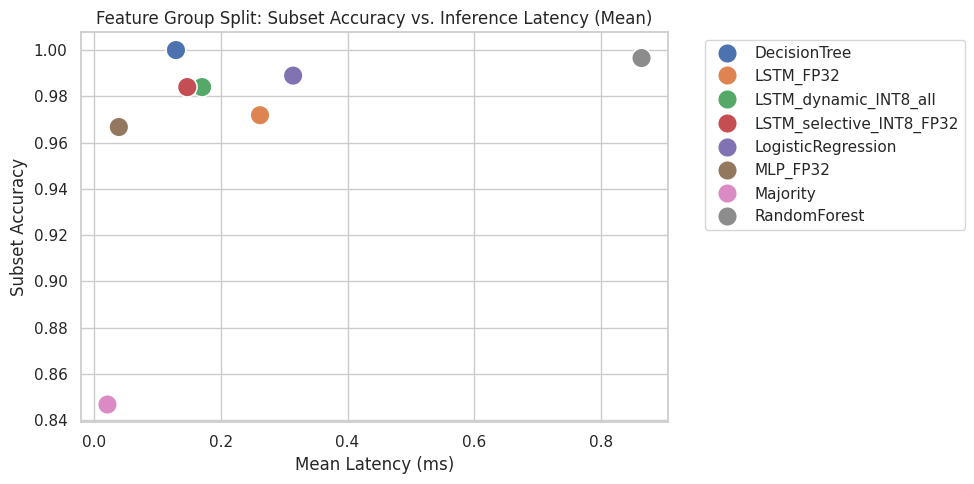

In [26]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style for clean visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# 1. Load summary data across the three experimental protocols
protocols = ['chronological_T1_final', 'chronological_T12', 'feature_group_T1_final']
df_list = []

for protocol in protocols:
    path = OUT / protocol / 'summary.csv'
    if path.exists():
        df = pd.read_csv(path)
        df['Protocol'] = protocol
        df_list.append(df)

if df_list:
    all_summaries = pd.concat(df_list, ignore_index=True)
    print("--- EXPERIMENT RESULTS SUMMARY TABLE ---")
    display(all_summaries[['Protocol', 'model', 'subset_accuracy_mean', 'model_latency_mean_ms']])

    # 2. Plot Accuracy vs. Latency for Feature Group Protocol (where variation is present)
    fg_data = all_summaries[all_summaries['Protocol'] == 'feature_group_T1_final']
    if not fg_data.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.scatterplot(
            data=fg_data,
            x='model_latency_mean_ms',
            y='subset_accuracy_mean',
            hue='model',
            s=200,
            ax=ax
        )
        ax.set_title("Feature Group Split: Subset Accuracy vs. Inference Latency (Mean)")
        ax.set_xlabel("Mean Latency (ms)")
        ax.set_ylabel("Subset Accuracy")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("Summary files not found in the run folder.")

# 3. Load and plot group bootstrap confidence intervals (Seed 42)
stats_path = OUT / 'statistical_analysis.json'
if stats_path.exists():
    stats_data = json.loads(stats_path.read_text())
    bootstrap_data = stats_data.get('seed42_group_bootstrap', {})

    models_list = []
    low_cis = []
    high_cis = []
    means = []

    for model, info in bootstrap_data.items():
        models_list.append(model)
        means.append(info['subset_accuracy'])
        low_cis.append(info['conditional_feature_group_bootstrap_95CI'][0])
        high_cis.append(info['conditional_feature_group_bootstrap_95CI'][1])

    bootstrap_df = pd.DataFrame({
        'Model': models_list,
        'Accuracy': means,
        'CI_Lower': low_cis,
        'CI_Upper': high_cis
    }).sort_values(by='Accuracy', ascending=True)

    print("\n--- SEED 42 FEATURE-GROUP BOOTSTRAP 95% CONFIDENCE INTERVALS ---")
    display(bootstrap_df)

    # Plot Confidence Intervals
    fig, ax = plt.subplots(figsize=(10, 6))
    y_positions = range(len(bootstrap_df))
    ax.errorbar(
        bootstrap_df['Accuracy'],
        y_positions,
        xerr=[bootstrap_df['Accuracy'] - bootstrap_df['CI_Lower'], bootstrap_df['CI_Upper'] - bootstrap_df['Accuracy']],
        fmt='o',
        color='teal',
        ecolor='gray',
        capsize=5,
        markersize=8,
        label='95% Bootstrap CI'
    )
    ax.set_yticks(y_positions)
    ax.set_yticklabels(bootstrap_df['Model'])
    ax.set_xlabel("Subset Accuracy")
    ax.set_title("95% Conditional Feature-Group Bootstrap Intervals (Seed 42)")
    plt.tight_layout()
    plt.show()


In [27]:
from google.colab import files

# Configure a clean dataframe for external reporting
report_df = all_summaries[[
    'Protocol',
    'model',
    'subset_accuracy_mean',
    'subset_accuracy_sd',
    'model_latency_mean_ms',
    'model_latency_between_run_sd_ms'
]].copy()

# Rename columns to clear, publication-ready headers
report_df.columns = [
    'Evaluation Protocol',
    'Model Architecture',
    'Mean Subset Accuracy',
    'Subset Accuracy SD',
    'Mean Latency (ms)',
    'Latency Between-Run SD (ms)'
]

# Define output path
export_path = WORK / 'experiment_summary_report.csv'
report_df.to_csv(export_path, index=False)
print(f"Successfully exported clean report table to: {export_path}")

# Trigger automatic browser download of the exported CSV
files.download(str(export_path))

Successfully exported clean report table to: /content/sasqof_asr646/experiment_summary_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>